# EN3160 Assignment 1
## Intensity Transformations and Neighborhood Filtering

**Working notebook: Questions 1-3**

Name and index number: to be filled in before submission.

GitHub profile: [ahesh-dilhan](https://github.com/ahesh-dilhan).

Source: *en3160_assignment_01.pdf*, Ranga Rodrigo, September 2, 2026.
The final report must be exported directly from the notebook, contain at most
10 pages, and include code, results, comparisons, and discussion.


## 1. Piecewise-linear intensity transformations

A grayscale pixel stores a brightness value from 0 (black) to 255 (white).
An intensity transformation replaces each input brightness $r$ with an output
brightness $T(r)$ without changing the pixel's position.

We will implement `intensity_transform(im, breakpoints)`, reproduce Figure 1a,
compare the example matrix, and experiment with alternative breakpoints.

The source is the 720 x 810 grayscale portrait embedded in Figure 1b.
It was extracted as a JPEG directly from the PDF; it is not a screenshot.
A separately supplied original image has not yet been located.


In [1]:
from pathlib import Path

import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display

PROJECT_DIR = Path.cwd()
if not (PROJECT_DIR / "data" / "q1_portrait.jpg").is_file():
    raise FileNotFoundError("Open the notebook from the CVPR project directory.")
OUTPUT_DIR = PROJECT_DIR / "output" / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
})

image_path = PROJECT_DIR / "data" / "q1_portrait.jpg"
original = cv.imread(str(image_path), cv.IMREAD_GRAYSCALE)
if original is None:
    raise FileNotFoundError(f"Could not read {image_path}")
print(f"Image: {original.shape[1]} x {original.shape[0]}, dtype={original.dtype}")


Image: 720 x 810, dtype=uint8


### How the transformation works

Between consecutive breakpoints $(x_i,y_i)$ and $(x_{i+1},y_{i+1})$ with distinct
input coordinates, use linear interpolation:

$$
T(r) = y_i + \frac{r-x_i}{x_{i+1}-x_i}(y_{i+1}-y_i).
$$

A segment above the line $T(r)=r$ brightens that intensity range.
A segment below it darkens the range. Its slope determines how much neighboring
input intensities are separated in the output.

There are only 256 possible input values in an 8-bit image, so the function
builds a 256-entry lookup table and uses it to transform the entire image.
Interpolation uses floating-point arithmetic, then outputs are rounded to the
nearest integer with `np.rint` (ties to even) and stored as `uint8`.


In [2]:
def intensity_transform(im, breakpoints):
    """Transform a uint8 image; duplicate input points use the last output."""
    im = np.asarray(im)
    points = np.asarray(breakpoints, dtype=np.float64)
    if im.dtype != np.uint8:
        raise TypeError("im must contain 8-bit unsigned integer intensities.")
    if points.ndim != 2 or points.shape[1] != 2 or len(points) < 2:
        raise ValueError("breakpoints must be an N x 2 array with N >= 2.")
    if not np.isfinite(points).all() or np.any((points < 0) | (points > 255)):
        raise ValueError("All breakpoint coordinates must be finite and in [0, 255].")

    x, y = points.T
    if x[0] != 0 or x[-1] != 255 or np.any(np.diff(x) < 0):
        raise ValueError("Input coordinates must run from 0 to 255 in sorted order.")

    levels = np.arange(256, dtype=np.float64)
    # Select the last point at each input, so vertical jumps skip zero-width segments.
    left = np.searchsorted(x, levels, side="right") - 1
    mapped = y[left].copy()
    between = left < len(x) - 1
    start = left[between]
    fraction = (levels[between] - x[start]) / (x[start + 1] - x[start])
    mapped[between] += fraction * (y[start + 1] - y[start])

    lookup = np.clip(np.rint(mapped), 0, 255).astype(np.uint8)
    return lookup[im]


### Figure 1a and the example matrix differ

Figure 1a jumps from output 50 to 100 at input 50, rises to 255 just before input
150, then drops to 150 at input 150. It returns to the identity line above 150.

The example matrix in the question instead gives the pairs
$(0,0),(50,50),(100,150),(150,255),(255,255)$.
Linear interpolation through these pairs is continuous and maps every input
from 150 to 255 to white. These are different transformations, so both are
reported explicitly.

To represent the plotted jumps, we repeat an input coordinate with its
before-jump and after-jump outputs. At the exact input, the function chooses
the **last listed output**. Thus $T(50)=100$ and $T(150)=150$ for the figure.
This is a stated implementation convention because the plotted vertical lines
do not specify a unique output at those exact inputs.

All breakpoint lists must span inputs 0 through 255. The function rejects
unsorted inputs and out-of-range coordinates instead of silently correcting them.


In [3]:
FIGURE_BREAKPOINTS = np.array([
    [0, 0],
    [50, 50],
    [50, 100],
    [150, 255],
    [150, 150],
    [255, 255],
], dtype=float)

EXAMPLE_BREAKPOINTS = np.array([
    [0, 0],
    [50, 50],
    [100, 150],
    [150, 255],
    [255, 255],
], dtype=float)

figure_result = intensity_transform(original, FIGURE_BREAKPOINTS)
example_result = intensity_transform(original, EXAMPLE_BREAKPOINTS)


### Implementation checks

The checks below cover identity, decreasing output values, interpolation,
the figure's jumps, repeated endpoints, preservation of image shape and type,
and invalid breakpoint inputs. They use independently specified expected
pixel values. This validation cell can be omitted from the final compact report.


In [4]:
ramp = np.arange(256, dtype=np.uint8)
assert np.array_equal(intensity_transform(ramp, [[0, 0], [255, 255]]), ramp)

pixels = np.array([0, 49, 50, 51, 100, 149, 150, 151, 255], dtype=np.uint8)
assert np.array_equal(
    intensity_transform(pixels, FIGURE_BREAKPOINTS),
    [0, 49, 100, 102, 178, 253, 150, 151, 255],
)
assert np.array_equal(
    intensity_transform(np.array([0, 25, 50, 75, 100, 150, 255], dtype=np.uint8),
                        EXAMPLE_BREAKPOINTS),
    [0, 25, 50, 100, 150, 255, 255],
)
assert np.array_equal(
    intensity_transform(np.array([0, 64, 128, 255], dtype=np.uint8),
                        [[0, 255], [255, 0]]),
    [255, 191, 127, 0],
)
assert np.array_equal(
    intensity_transform(np.array([0, 255], dtype=np.uint8),
                        [[0, 0], [255, 128], [255, 255]]),
    [0, 255],
)
assert np.array_equal(
    intensity_transform(np.array([0, 255], dtype=np.uint8),
                        [[0, 0], [0, 70], [255, 255]]),
    [70, 255],
)
assert figure_result.shape == original.shape
assert figure_result.dtype == np.uint8

for invalid in (
    [[0, 0]], [[0, 0], [200, 150], [100, 120], [255, 255]],
    [[1, 0], [255, 255]], [[0, 0], [255, 256]],
    [[0, 0], [255, np.nan]],
):
    try:
        intensity_transform(ramp, invalid)
    except ValueError:
        pass
    else:
        raise AssertionError(f"Accepted invalid breakpoints: {invalid}")

try:
    intensity_transform(ramp.astype(float), [[0, 0], [255, 255]])
except TypeError:
    pass
else:
    raise AssertionError("Accepted a non-uint8 image.")

print("All transformation checks passed.")


All transformation checks passed.


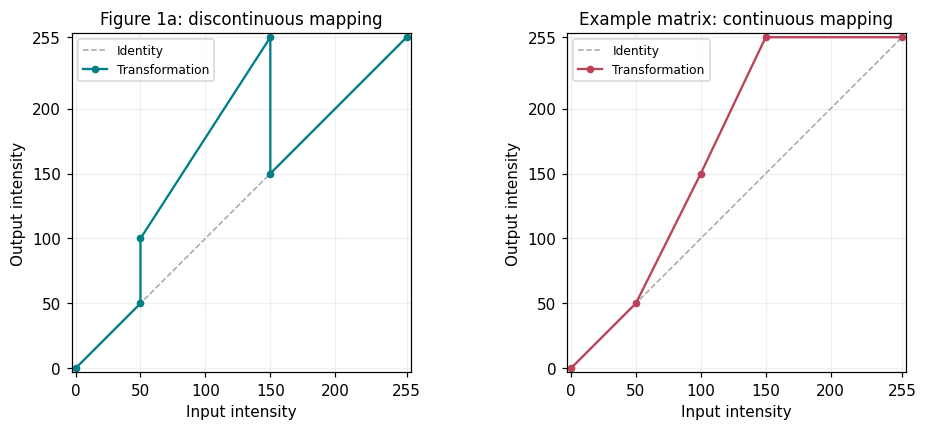

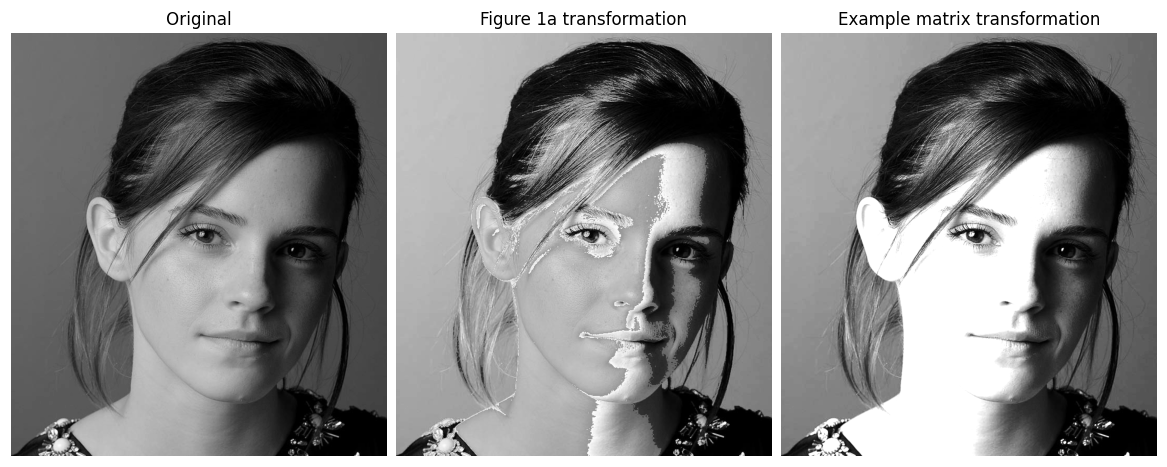

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.8), layout="constrained")
for ax, points, title, color in [
    (axes[0], FIGURE_BREAKPOINTS, "Figure 1a: discontinuous mapping", "#007f86"),
    (axes[1], EXAMPLE_BREAKPOINTS, "Example matrix: continuous mapping", "#bb4258"),
]:
    ax.plot([0, 255], [0, 255], "--", color="0.65", linewidth=1, label="Identity")
    ax.plot(points[:, 0], points[:, 1], "o-", color=color, markersize=4,
            label="Transformation")
    ax.set(xlim=(-3, 258), ylim=(-3, 258), xlabel="Input intensity",
           ylabel="Output intensity", title=title)
    ax.set_xticks([0, 50, 100, 150, 200, 255])
    ax.set_yticks([0, 50, 100, 150, 200, 255])
    ax.set_aspect("equal")
    ax.grid(alpha=0.2)
    ax.legend(fontsize=8)
fig.savefig(OUTPUT_DIR / "q1_assignment_transformations.png", dpi=160)
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(10.5, 4.4), layout="constrained")
for ax, im, title in zip(
    axes, [original, figure_result, example_result],
    ["Original", "Figure 1a transformation", "Example matrix transformation"],
):
    ax.imshow(im, cmap="gray", vmin=0, vmax=255)
    ax.set_title(title)
    ax.axis("off")
fig.savefig(OUTPUT_DIR / "q1_assignment_comparison.png", dpi=160)
plt.show()


### Breakpoint experiments

We now try three continuous, increasing mappings.
Keeping the outputs increasing preserves the order of pixel brightnesses.

- **Gentle lift:** a modest increase in shadows and midtones.
- **Contrast lift:** darker deep shadows with brighter midtones.
- **Strong lift:** a larger brightness increase, including already bright regions.

All image panels use the same fixed display range of 0 to 255. Independent
automatic display scaling could otherwise conceal the effect of a transformation.


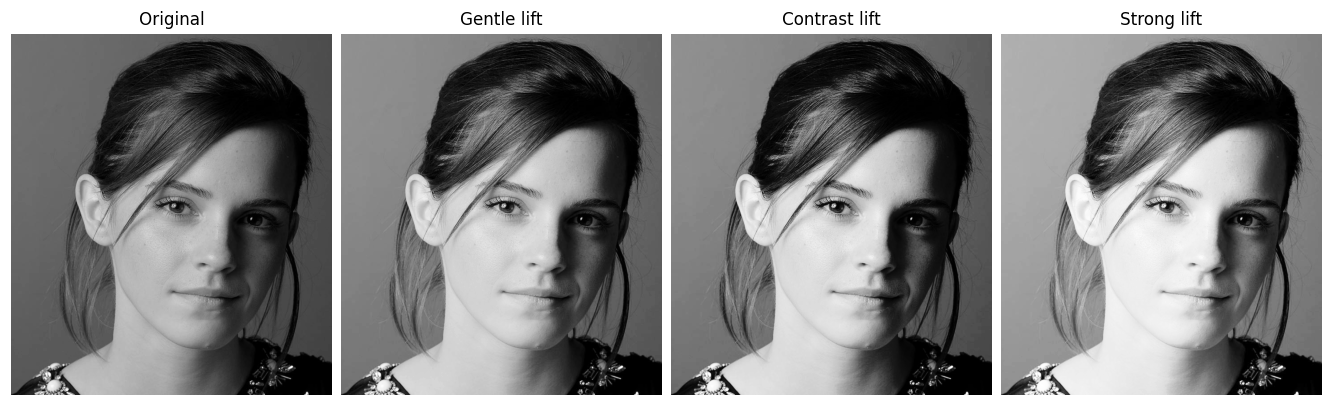

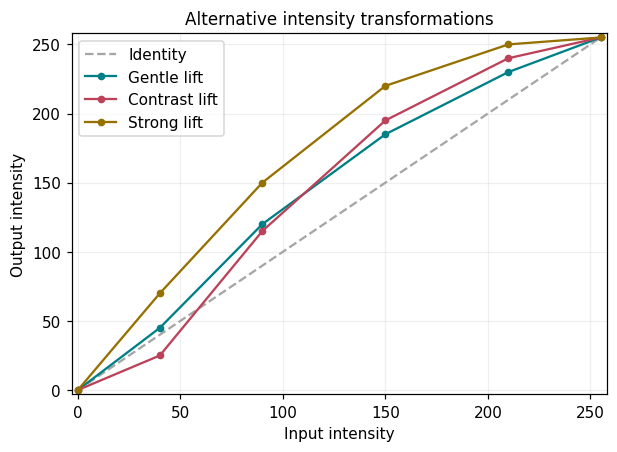

In [6]:
EXPERIMENTS = {
    "Gentle lift": [[0, 0], [40, 45], [90, 120], [150, 185], [210, 230], [255, 255]],
    "Contrast lift": [[0, 0], [40, 25], [90, 115], [150, 195], [210, 240], [255, 255]],
    "Strong lift": [[0, 0], [40, 70], [90, 150], [150, 220], [210, 250], [255, 255]],
}
experiment_results = {
    name: intensity_transform(original, points)
    for name, points in EXPERIMENTS.items()
}

fig, axes = plt.subplots(1, 4, figsize=(12, 4), layout="constrained")
for ax, (name, im) in zip(
    axes, [("Original", original), *experiment_results.items()]
):
    ax.imshow(im, cmap="gray", vmin=0, vmax=255)
    ax.set_title(name)
    ax.axis("off")
fig.savefig(OUTPUT_DIR / "q1_experiment_comparison.png", dpi=160)
plt.show()

fig, ax = plt.subplots(figsize=(5.5, 4), layout="constrained")
ax.plot([0, 255], [0, 255], "--", color="0.65", label="Identity")
for (name, points), color in zip(EXPERIMENTS.items(), ["#007f86", "#bb4258", "#967000"]):
    points = np.asarray(points)
    ax.plot(points[:, 0], points[:, 1], "o-", label=name, color=color, markersize=4)
ax.set(xlim=(-3, 258), ylim=(-3, 258), xlabel="Input intensity",
       ylabel="Output intensity", title="Alternative intensity transformations")
ax.grid(alpha=0.2)
ax.legend()
fig.savefig(OUTPUT_DIR / "q1_experiment_transformations.png", dpi=160)
plt.show()


### Selected result

The initial selection is **Gentle lift**. This is a visual preference for this
portrait, not a universally optimal transformation. Change `SELECTED_NAME`
below to compare a different candidate.


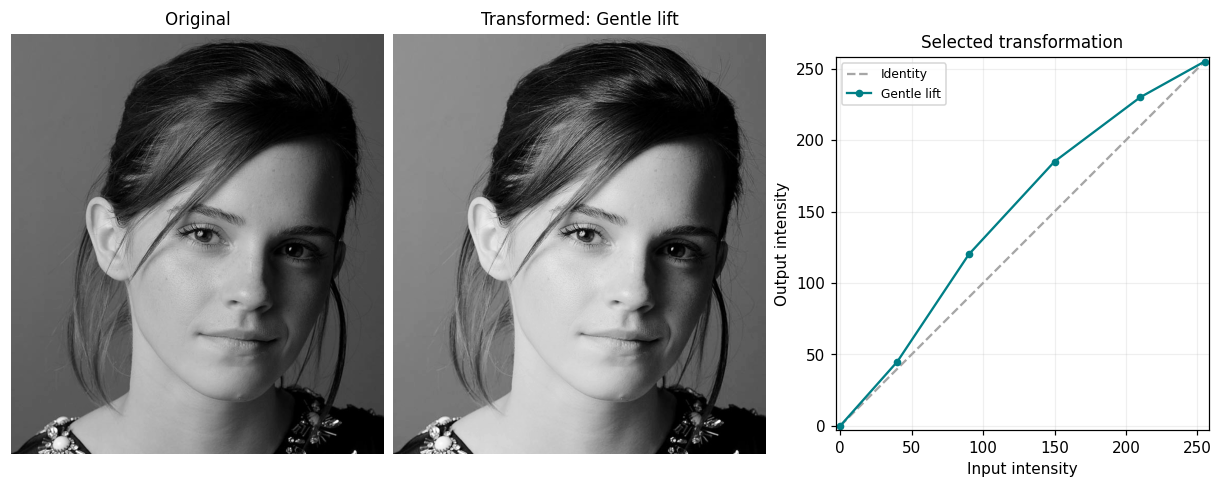

| Image | Mean intensity | Pixels at 255 (%) |
|---|---:|---:|
| Original | 92.22 | 0.013 |
| Figure 1a | 133.35 | 0.013 |
| Example matrix | 131.15 | 19.876 |
| Gentle lift | 113.49 | 0.013 |
| Contrast lift | 110.54 | 0.015 |
| Strong lift | 138.69 | 0.022 |

In [7]:
SELECTED_NAME = "Gentle lift"
selected_breakpoints = np.asarray(EXPERIMENTS[SELECTED_NAME], dtype=float)
selected_result = experiment_results[SELECTED_NAME]

fig, axes = plt.subplots(1, 3, figsize=(11, 4.6), layout="constrained")
axes[0].imshow(original, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Original")
axes[0].axis("off")
axes[1].imshow(selected_result, cmap="gray", vmin=0, vmax=255)
axes[1].set_title(f"Transformed: {SELECTED_NAME}")
axes[1].axis("off")
axes[2].plot([0, 255], [0, 255], "--", color="0.65", label="Identity")
axes[2].plot(selected_breakpoints[:, 0], selected_breakpoints[:, 1],
             "o-", color="#007f86", markersize=4, label=SELECTED_NAME)
axes[2].set(xlim=(-3, 258), ylim=(-3, 258), xlabel="Input intensity",
            ylabel="Output intensity", title="Selected transformation")
axes[2].set_aspect("equal")
axes[2].grid(alpha=0.2)
axes[2].legend(fontsize=8)
fig.savefig(OUTPUT_DIR / "q1_selected_result.png", dpi=160, bbox_inches="tight")
plt.show()

all_results = {
    "Original": original,
    "Figure 1a": figure_result,
    "Example matrix": example_result,
    **experiment_results,
}
rows = ["| Image | Mean intensity | Pixels at 255 (%) |",
        "|---|---:|---:|"]
for name, im in all_results.items():
    rows.append(f"| {name} | {im.mean():.2f} | {100 * np.mean(im == 255):.3f} |")
display(Markdown("\n".join(rows)))


### Interpretation and discussion

The figure's transformation is nonmonotonic: a pixel with input 149 becomes
253, whereas a slightly brighter pixel with input 150 becomes 150. This
reverses their relative brightness and can introduce abrupt tonal boundaries.
It demonstrates the requested mapping, but it is not automatically a good
enhancement for a portrait.

The example matrix is monotonic but has a flat final segment. Every pixel with
input at least 150 becomes 255, so distinct bright intensities become
indistinguishable. A large mean brightness therefore does not by itself imply
a better result.

The three experimental curves lift midtones by different amounts. Gentle lift
keeps the mapping continuous and increasing, with more restrained brightening
than Strong lift. It also avoids the example matrix's flat white plateau.
The numerical table reports mean intensity and the fraction of pixels at white
as descriptive checks; neither is a complete measure of visual quality.

Intensity transformations change tonal relationships, not spatial resolution.
They cannot recover details that were absent from the input. Even a strictly
increasing continuous curve can merge some intensities after 8-bit rounding.

**Current preference:** Gentle lift. Review the displayed portrait before
settling on the final breakpoints; visual preference remains subjective.


### Check your understanding

1. Why does a curve above the identity line brighten pixels?
2. How does a steep segment affect contrast within its input range?
3. Why does mapping every value from 150 to 255 to white lose detail?
4. Why must Figure 1a's jumps be handled differently from ordinary interpolation?
5. Why are all comparisons displayed with the same grayscale limits?

Question 1 now includes the function, the assignment's two different mappings,
three breakpoint experiments, the selected transformation plot, image
comparisons, and a discussion.


## 2. Accentuating white matter and gray matter

**Task:** apply intensity transformations to the proton-density brain slice in
Figure 2 to emphasize (a) white matter and (b) gray matter, and plot the
transformations. We reuse `intensity_transform` from Question 1.

In this image, the relatively dark interior is associated with white matter
(WM), while the brighter cortical tissue is associated with gray matter (GM).
The tissue names do not specify their displayed brightness. This ordering is
consistent with proton-density contrast; see D. B. Plewes,
[Contrast Mechanisms in Spin-Echo MR Imaging](https://mriquestions.com/uploads/3/4/5/7/34572113/radiographics2e142e62e7855348_-se_contrrast.pdf),
*RadioGraphics* 14 (1994), pp. 1389-1404, especially p. 1395.

We use **intensity-band highlighting**: brighten a chosen range and suppress
intensities outside it. The input is the 181 x 217 image embedded in the
assignment PDF, loaded as 8-bit grayscale.


### Inspecting the input

Three small reference patches are selected visually: an interior WM-like
region, a cortical GM-like region, and a bright ventricular region associated
with cerebrospinal fluid (CSF). The rectangles show exactly where values are
sampled. Coordinates are `(x, y, width, height)` in pixels, starting at the
top-left corner.

Their histograms and percentiles help select image-specific breakpoints.
These patches are illustrative and can contain mixed tissues, particularly
near boundaries. They are not ground-truth segmentation labels or universal
MRI intensity ranges.


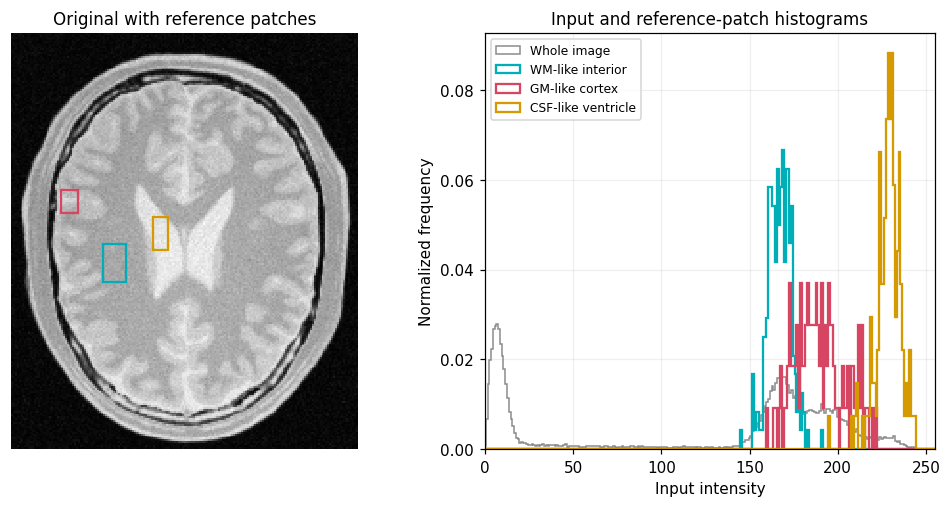

| Reference patch | (x, y, width, height) | 10th percentile | Median | 90th percentile |
|---|---|---:|---:|---:|
| WM-like interior | (48, 110, 12, 20) | 159.9 | 167.0 | 174.1 |
| GM-like cortex | (26, 82, 9, 12) | 173.0 | 188.0 | 211.3 |
| CSF-like ventricle | (74, 96, 8, 17) | 220.0 | 229.0 | 236.0 |

In [8]:
from matplotlib.patches import Rectangle

brain_path = PROJECT_DIR / "data" / "q2_brain_pd.png"
brain = cv.imread(str(brain_path), cv.IMREAD_GRAYSCALE)
if brain is None:
    raise FileNotFoundError(f"Could not read {brain_path}")

REFERENCE_PATCHES = {
    "WM-like interior": (48, 110, 12, 20),
    "GM-like cortex": (26, 82, 9, 12),
    "CSF-like ventricle": (74, 96, 8, 17),
}
reference_colors = ["#00aeb8", "#d64562", "#d59a00"]

fig, axes = plt.subplots(1, 2, figsize=(9, 4.5), layout="constrained")
axes[0].imshow(brain, cmap="gray", vmin=0, vmax=255, interpolation="nearest")
axes[0].set_title("Original with reference patches")
axes[0].axis("off")

bins = np.arange(257) - 0.5
axes[1].hist(brain.ravel(), bins=bins, density=True, histtype="step",
             color="0.55", linewidth=1, label="Whole image")
reference_rows = [
    "| Reference patch | (x, y, width, height) | 10th percentile | Median | 90th percentile |",
    "|---|---|---:|---:|---:|",
]
for (name, (x, y, width, height)), color in zip(REFERENCE_PATCHES.items(), reference_colors):
    patch = brain[y:y + height, x:x + width]
    assert patch.size == width * height
    axes[0].add_patch(Rectangle((x - 0.5, y - 0.5), width, height,
                               fill=False, edgecolor=color, linewidth=1.5))
    axes[1].hist(patch.ravel(), bins=bins, density=True, histtype="step",
                 color=color, linewidth=1.5, label=name)
    p10, median, p90 = np.percentile(patch, [10, 50, 90])
    reference_rows.append(
        f"| {name} | {(x, y, width, height)} | {p10:.1f} | {median:.1f} | {p90:.1f} |"
    )
axes[1].set(xlim=(0, 255), xlabel="Input intensity", ylabel="Normalized frequency",
            title="Input and reference-patch histograms")
axes[1].grid(alpha=0.2)
axes[1].legend(fontsize=8)
fig.savefig(OUTPUT_DIR / "q2_reference_regions.png", dpi=160, bbox_inches="tight")
plt.show()
display(Markdown("\n".join(reference_rows)))


### Choosing the transformations

A trapezoidal curve has a rising edge, a bright plateau, and a falling edge.
For ordered inputs $a<b<c<d$, the output is:

$$
T(r)=
\begin{cases}
0, & r\le a,\\
255(r-a)/(b-a), & a<r<b,\\
255, & b\le r\le c,\\
255(d-r)/(d-c), & c<r<d,\\
0, & r\ge d.
\end{cases}
$$

| Target | Rising transition | Full-brightness band | Falling transition |
|---|---|---|---|
| White matter | 140 to 155 | 155 to 175 | 175 to 190 |
| Gray matter | 170 to 185 | 185 to 205 | 205 to 220 |

The interior sample is centered near 167, while the cortical sample is centered
near 188. The bands are chosen around those observed ranges. Very dark
background values and the brightest ventricular-fluid values are suppressed.

Both curves are continuous, but nonmonotonic: values brighter than the target
band become dark again. Unlike Question 1's portrait enhancement, the aim here
is selective highlighting rather than preserving the order of all brightnesses.
The transitions overlap, so these curves do not partition the image into tissue
classes.


In [9]:
WM_BREAKPOINTS = np.array([
    [0, 0], [140, 0], [155, 255],
    [175, 255], [190, 0], [255, 0],
], dtype=float)

GM_BREAKPOINTS = np.array([
    [0, 0], [170, 0], [185, 255],
    [205, 255], [220, 0], [255, 0],
], dtype=float)

white_matter_enhanced = intensity_transform(brain, WM_BREAKPOINTS)
gray_matter_enhanced = intensity_transform(brain, GM_BREAKPOINTS)


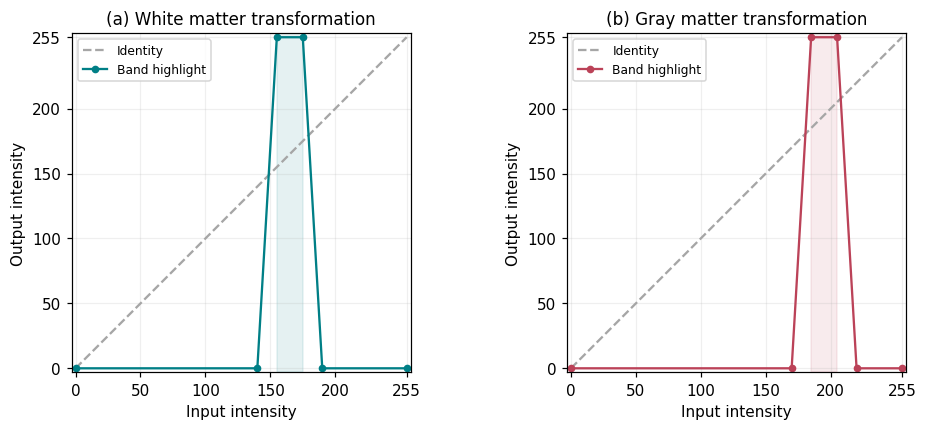

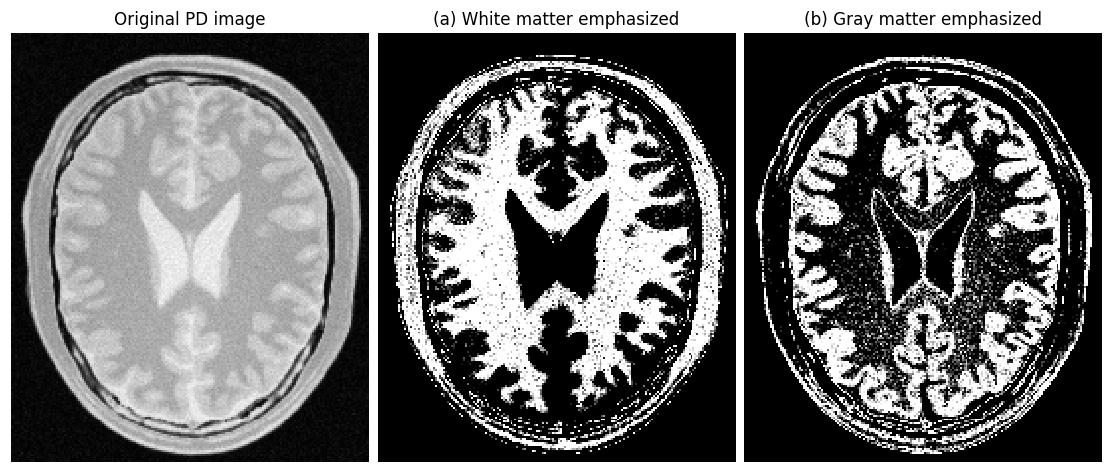

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.8), layout="constrained")
for ax, points, title, color in [
    (axes[0], WM_BREAKPOINTS, "(a) White matter transformation", "#007f86"),
    (axes[1], GM_BREAKPOINTS, "(b) Gray matter transformation", "#bb4258"),
]:
    ax.plot([0, 255], [0, 255], "--", color="0.65", label="Identity")
    ax.plot(points[:, 0], points[:, 1], "o-", color=color, markersize=4,
            label="Band highlight")
    ax.axvspan(points[2, 0], points[3, 0], color=color, alpha=0.1)
    ax.set(xlim=(-3, 258), ylim=(-3, 258), xlabel="Input intensity",
           ylabel="Output intensity", title=title)
    ax.set_xticks([0, 50, 100, 150, 200, 255])
    ax.set_yticks([0, 50, 100, 150, 200, 255])
    ax.set_aspect("equal")
    ax.grid(alpha=0.2)
    ax.legend(fontsize=8)
fig.savefig(OUTPUT_DIR / "q2_intensity_transformations.png", dpi=160, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(10, 4.3), layout="constrained")
for ax, im, title in zip(
    axes, [brain, white_matter_enhanced, gray_matter_enhanced],
    ["Original PD image", "(a) White matter emphasized", "(b) Gray matter emphasized"],
):
    ax.imshow(im, cmap="gray", vmin=0, vmax=255, interpolation="nearest")
    ax.set_title(title)
    ax.axis("off")
fig.savefig(OUTPUT_DIR / "q2_tissue_comparison.png", dpi=160, bbox_inches="tight")
plt.show()


### Checking the selected bands

We check that the outputs preserve the image dimensions and 8-bit type, that
representative target intensities are highlighted, and that background and
very bright inputs are suppressed. We also compare the mean outputs in the
same reference patches. These are checks on the selected parameters, not a
measurement of tissue-segmentation accuracy.


In [11]:
probes = np.array([0, 167, 195, 230, 255], dtype=np.uint8)
assert np.array_equal(
    intensity_transform(probes, WM_BREAKPOINTS), [0, 255, 0, 0, 0]
)
assert np.array_equal(
    intensity_transform(probes, GM_BREAKPOINTS), [0, 0, 255, 0, 0]
)
for enhanced in [white_matter_enhanced, gray_matter_enhanced]:
    assert enhanced.shape == brain.shape
    assert enhanced.dtype == np.uint8

reference_means = {}
comparison_rows = [
    "| Reference patch | Original mean | WM-enhanced mean | GM-enhanced mean |",
    "|---|---:|---:|---:|",
]
for name, (x, y, width, height) in REFERENCE_PATCHES.items():
    means = [
        float(im[y:y + height, x:x + width].mean())
        for im in [brain, white_matter_enhanced, gray_matter_enhanced]
    ]
    reference_means[name] = means
    comparison_rows.append(
        f"| {name} | {means[0]:.2f} | {means[1]:.2f} | {means[2]:.2f} |"
    )
assert reference_means["WM-like interior"][1] > reference_means["WM-like interior"][2]
assert reference_means["GM-like cortex"][2] > reference_means["GM-like cortex"][1]
display(Markdown("\n".join(comparison_rows)))
print("Question 2 shape, type, intensity-band, and reference-patch checks passed.")


| Reference patch | Original mean | WM-enhanced mean | GM-enhanced mean |
|---|---:|---:|---:|
| WM-like interior | 167.17 | 247.70 | 22.81 |
| GM-like cortex | 189.78 | 86.26 | 179.13 |
| CSF-like ventricle | 228.79 | 0.00 | 9.25 |

Question 2 shape, type, intensity-band, and reference-patch checks passed.


### Interpretation and discussion

The white-matter transformation emphasizes the branching interior structures
and suppresses most brighter cortical tissue. The gray-matter transformation
instead emphasizes the cortical pattern and other regions with similar
intensities. The reference-patch table confirms that the WM-like sample is
brighter under the WM mapping and the GM-like sample is brighter under the
GM mapping.

Bright ventricular-fluid regions are largely suppressed by both curves.
However, some scalp structures, tissue boundaries, and isolated pixels also
become bright. The function uses only intensity: equal input values always
receive equal outputs, regardless of tissue identity or pixel location.
Noise and pixels containing a mixture of tissues contribute to this overlap.

The gradual ramps reduce abrupt changes compared with a binary threshold,
but the flat plateau deliberately removes intensity variation within the
highlighted band. A narrower band would reject more neighboring intensities
while potentially losing more of the intended tissue. A broader band would
highlight more tissue but also more unwanted structures. The chosen bands
provide a visible separation in this particular image; they are not unique
or universally optimal.

All panels use the same 0-255 display limits and nearest-neighbor display
interpolation. The input is a small 181 x 217 image, and enlarging the display
does not add anatomical detail. No spatial mask or labeled tissue map was
used to produce either result.


### Check your understanding

1. Why can white matter appear darker than gray matter in this image?
2. What happens to a pixel with intensity 167 under each transformation?
3. Why do very bright pixels become dark under both curves?
4. Why can parts of the scalp appear in a tissue-highlighted result?
5. What information is lost when a range is mapped to a flat plateau?

Question 2 now includes separate WM and GM transformations, their plots,
original/result comparisons, parameter checks, and interpretation.


## 3. Gamma correction in Lab color space

**Task:** apply gamma correction to the L plane of the Figure 3 photograph,
report the gamma value, and compare the histograms of the original and
corrected images.

The photograph contains dark rocks alongside a bright skirt. We will lift the
darker regions by changing lightness while retaining the original Lab color
coordinates during the transformation.

The 720 x 480 JPEG is extracted directly from Figure 3 in the assignment PDF.
OpenCV reads it in BGR order, so it is converted to RGB for display.


### Lightness scaling and gamma convention

Lab separates lightness $L^*$ from color coordinates $a^*$ and $b^*$.
We convert the input to floating point in the range 0 to 1 before calling
`cvtColor`. OpenCV then represents $L^*$ in the range 0 to 100; this differs
from its 8-bit Lab encoding, which scales lightness to 0 to 255.
See the [OpenCV color-conversion documentation](https://docs.opencv.org/4.x/de/d25/imgproc_color_conversions.html).

The transformation is

$$
L_{\mathrm{out}}^*
= 100\left(\frac{L_{\mathrm{in}}^*}{100}\right)^\gamma.
$$

We use the **direct exponent** $\gamma$, not its reciprocal. Under this
convention, $0<\gamma<1$ brightens intermediate values, $\gamma=1$ leaves
lightness unchanged, and $\gamma>1$ darkens it. Black and white endpoints
remain fixed.

The correction operates on perceptual Lab lightness. It is not an exposure
adjustment in linear RGB or a camera/display gamma-calibration procedure.


In [12]:
photo_path = PROJECT_DIR / "data" / "q3_gamma_photo.jpg"
photo_bgr = cv.imread(str(photo_path), cv.IMREAD_COLOR)
if photo_bgr is None:
    raise FileNotFoundError(f"Could not read {photo_path}")

photo_rgb = cv.cvtColor(photo_bgr, cv.COLOR_BGR2RGB)
photo_lab = cv.cvtColor(photo_rgb.astype(np.float32) / 255.0, cv.COLOR_RGB2Lab)

def gamma_correct_lab(lab_image, gamma):
    """Return float32 Lab with gamma applied only to L* (range 0 to 100)."""
    if not np.isfinite(gamma) or gamma <= 0:
        raise ValueError("gamma must be finite and positive.")
    if lab_image.dtype != np.float32:
        raise TypeError("Use float32 Lab, with L* in the range 0 to 100.")
    corrected = lab_image.copy()
    normalized_l = np.clip(lab_image[..., 0] / 100.0, 0.0, 1.0)
    corrected[..., 0] = 100.0 * normalized_l ** gamma
    return corrected

print(f"Figure 3: {photo_rgb.shape[1]} x {photo_rgb.shape[0]}, RGB uint8")


Figure 3: 720 x 480, RGB uint8


### Comparing gamma values

We compare $\gamma=0.5$, $0.7$, and $0.9$ on the same image.
A smaller exponent gives a stronger lift. The main visual tradeoff is between
making the darker rocks more visible and retaining contrast in the brighter
skirt and surrounding scene.


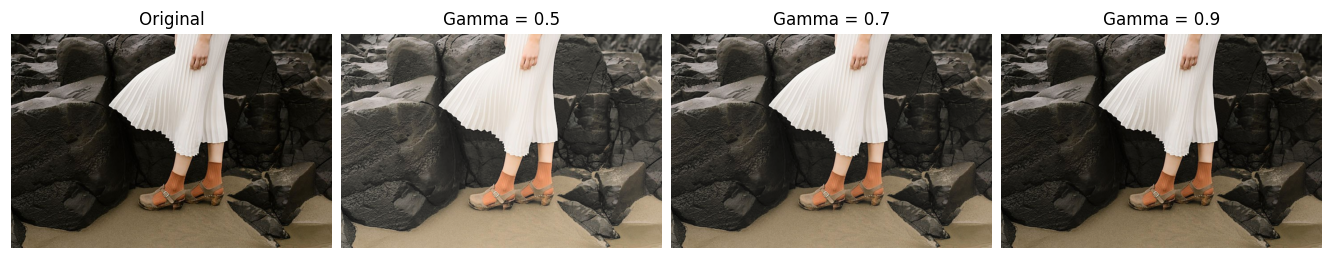

In [13]:
GAMMA_VALUES = [0.5, 0.7, 0.9]
gamma_lab_results = {
    gamma: gamma_correct_lab(photo_lab, gamma) for gamma in GAMMA_VALUES
}
gamma_rgb_results = {}
for gamma, corrected_lab in gamma_lab_results.items():
    rgb_float = cv.cvtColor(corrected_lab, cv.COLOR_Lab2RGB)
    gamma_rgb_results[gamma] = np.clip(
        np.rint(rgb_float * 255.0), 0, 255
    ).astype(np.uint8)

fig, axes = plt.subplots(1, 4, figsize=(12, 3), layout="constrained")
panels = [("Original", photo_rgb)] + [
    (f"Gamma = {gamma}", gamma_rgb_results[gamma]) for gamma in GAMMA_VALUES
]
for ax, (title, rgb) in zip(axes, panels):
    ax.imshow(rgb)
    ax.set_title(title)
    ax.axis("off")
fig.savefig(OUTPUT_DIR / "q3_gamma_experiments.png", dpi=160, bbox_inches="tight")
plt.show()


### Selected correction

**Selected gamma: 0.7**, using the direct-exponent formula above.
This is a moderate lift between the stronger 0.5 result and the subtler 0.9
result. The selection is a visual judgment for this photograph, not an
automatically optimized parameter.

The $a^*$ and $b^*$ arrays remain exactly unchanged in the corrected Lab image.
Converting that image back to RGB can introduce gamut clipping and rounding,
so exact preservation of the displayed colors is not guaranteed.


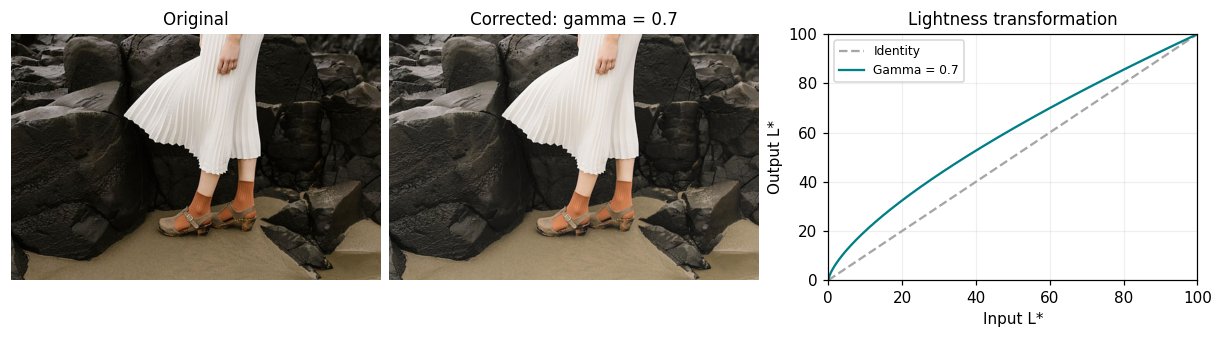

In [14]:
GAMMA = 0.7
corrected_photo_lab = gamma_lab_results[GAMMA]
corrected_photo_rgb = gamma_rgb_results[GAMMA]
original_lightness = photo_lab[..., 0]
target_lightness = corrected_photo_lab[..., 0]

# Reconvert the final RGB image so its measured histogram includes rendering changes.
rendered_photo_lab = cv.cvtColor(
    corrected_photo_rgb.astype(np.float32) / 255.0, cv.COLOR_RGB2Lab
)
rendered_lightness = rendered_photo_lab[..., 0]

fig, axes = plt.subplots(1, 3, figsize=(11, 3.7), layout="constrained")
for ax, rgb, title in [
    (axes[0], photo_rgb, "Original"),
    (axes[1], corrected_photo_rgb, f"Corrected: gamma = {GAMMA}"),
]:
    ax.imshow(rgb)
    ax.set_title(title)
    ax.axis("off")
lightness_axis = np.linspace(0.0, 100.0, 501)
axes[2].plot(lightness_axis, lightness_axis, "--", color="0.65", label="Identity")
axes[2].plot(lightness_axis, 100.0 * (lightness_axis / 100.0) ** GAMMA,
             color="#007f86", label=f"Gamma = {GAMMA}")
axes[2].set(xlim=(0, 100), ylim=(0, 100), xlabel="Input L*",
            ylabel="Output L*", title="Lightness transformation")
axes[2].set_box_aspect(2 / 3)
axes[2].grid(alpha=0.2)
axes[2].legend(fontsize=8)
fig.savefig(OUTPUT_DIR / "q3_selected_result.png", dpi=160, bbox_inches="tight")
plt.show()


### Histograms before and after correction

The top row compares Lab $L^*$, the quantity we transformed, using the same
bins and axis limits. The corrected histogram is measured from the final
8-bit RGB image converted back to Lab. The dashed curve shows the intended
$L^*$ values before that RGB conversion, allowing any conversion differences
to be seen.

The bottom row shows the three RGB channel histograms separately. These
describe the original and corrected color images; the channels are not
flattened together or treated as a single brightness measurement.


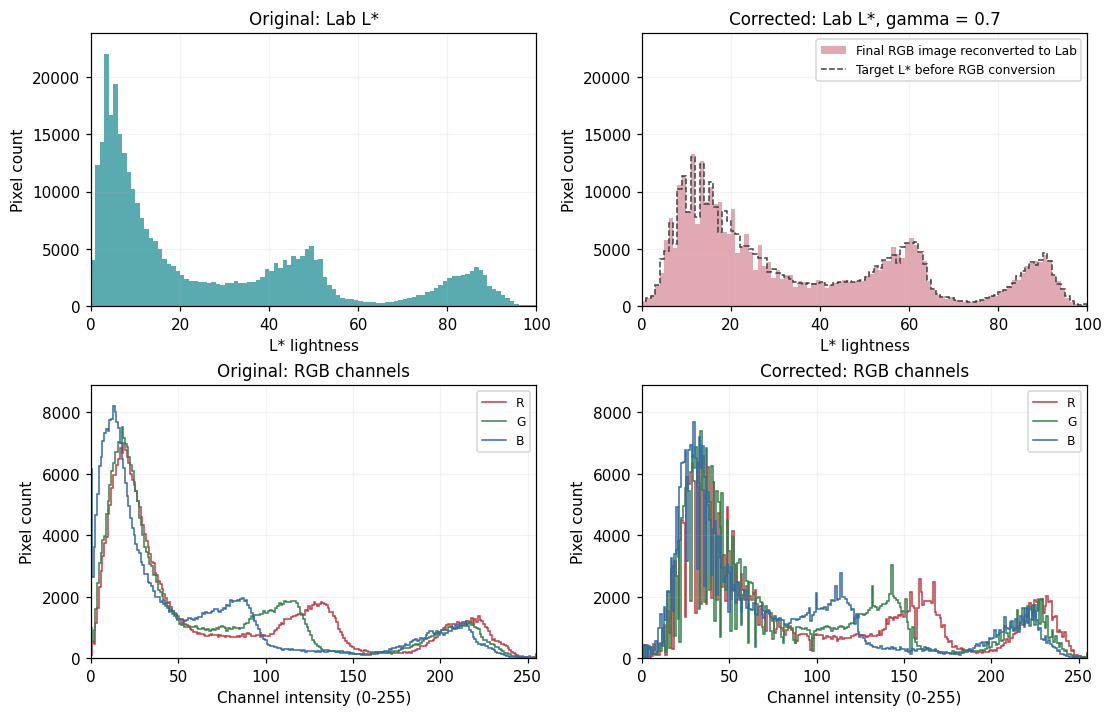

| Image | Mean L* | Median L* | Pixels with L* < 25 (%) |
|---|---:|---:|---:|
| Original | 27.88 | 14.73 | 59.39 |
| Corrected RGB image | 36.75 | 26.17 | 48.77 |

In [15]:
lightness_bins = np.linspace(0.0, 100.0, 101)
rgb_bins = np.arange(257) - 0.5
original_l_hist, _ = np.histogram(original_lightness, bins=lightness_bins)
corrected_l_hist, _ = np.histogram(rendered_lightness, bins=lightness_bins)
target_l_hist, _ = np.histogram(target_lightness, bins=lightness_bins)

fig, axes = plt.subplots(2, 2, figsize=(10, 6.4), layout="constrained")
axes[0, 0].stairs(original_l_hist, lightness_bins, color="#007f86", fill=True, alpha=0.65)
axes[0, 1].stairs(corrected_l_hist, lightness_bins, color="#bb4258",
                  fill=True, alpha=0.45, label="Final RGB image reconverted to Lab")
axes[0, 1].stairs(target_l_hist, lightness_bins, color="0.25",
                  linestyle="--", linewidth=1, label="Target L* before RGB conversion")
max_l_count = max(original_l_hist.max(), corrected_l_hist.max(), target_l_hist.max())
for ax, title in zip(axes[0], ["Original: Lab L*", f"Corrected: Lab L*, gamma = {GAMMA}"]):
    ax.set(xlim=(0, 100), ylim=(0, max_l_count * 1.08),
           xlabel="L* lightness", ylabel="Pixel count", title=title)
    ax.grid(alpha=0.15)
axes[0, 1].legend(fontsize=8)

max_rgb_count = 0
for ax, rgb, title in [
    (axes[1, 0], photo_rgb, "Original: RGB channels"),
    (axes[1, 1], corrected_photo_rgb, "Corrected: RGB channels"),
]:
    for channel, color, label in [(0, "#c53a45", "R"), (1, "#34834b", "G"), (2, "#326ba8", "B")]:
        counts, _ = np.histogram(rgb[..., channel], bins=rgb_bins)
        max_rgb_count = max(max_rgb_count, int(counts.max()))
        ax.stairs(counts, rgb_bins, color=color, linewidth=1, label=label)
    ax.set(xlim=(0, 255), xlabel="Channel intensity (0-255)",
           ylabel="Pixel count", title=title)
    ax.grid(alpha=0.15)
    ax.legend(fontsize=8)
for ax in axes[1]:
    ax.set_ylim(0, max_rgb_count * 1.08)
fig.savefig(OUTPUT_DIR / "q3_histogram_comparison.png", dpi=160, bbox_inches="tight")
plt.show()

summary_rows = [
    "| Image | Mean L* | Median L* | Pixels with L* < 25 (%) |",
    "|---|---:|---:|---:|",
]
for name, values in [("Original", original_lightness), ("Corrected RGB image", rendered_lightness)]:
    summary_rows.append(
        f"| {name} | {values.mean():.2f} | {np.median(values):.2f} "
        f"| {100 * np.mean(values < 25):.2f} |"
    )
display(Markdown("\n".join(summary_rows)))


### Implementation checks

The checks distinguish the exact Lab transformation from its RGB rendering:
gamma one is an identity in Lab, gamma below one increases intermediate
lightness, and the color coordinates are unchanged before conversion.
Histogram totals must account for every pixel.


In [16]:
probe_lab = np.array([[[0, 4, -6], [25, 4, -6], [100, 4, -6]]], dtype=np.float32)
probe_before = probe_lab.copy()
probe_result = gamma_correct_lab(probe_lab, 0.5)
assert np.allclose(probe_result[..., 0], [[0, 50, 100]])
assert np.array_equal(probe_lab, probe_before)
assert np.array_equal(probe_result[..., 1:], probe_lab[..., 1:])
assert np.allclose(gamma_correct_lab(photo_lab, 1.0), photo_lab, atol=1e-5)
assert np.array_equal(corrected_photo_lab[..., 1:], photo_lab[..., 1:])
assert np.all(target_lightness >= original_lightness - 1e-5)
assert np.isfinite(corrected_photo_lab).all()
assert corrected_photo_rgb.shape == photo_rgb.shape
assert corrected_photo_rgb.dtype == np.uint8
assert original_l_hist.sum() == corrected_l_hist.sum() == target_l_hist.sum() == original_lightness.size
print("Question 3 gamma, channel-preservation, image, and histogram checks passed.")


Question 3 gamma, channel-preservation, image, and histogram checks passed.


### Interpretation and discussion

For the selected direct exponent $\gamma=0.7$, intermediate lightness values
move upward. The low-lightness population shifts toward higher values in the
histogram, making the existing texture in the darker rocks easier to see.
The mean and median lightness increase, and fewer pixels remain below
$L^*=25$ in the final RGB image.

The 0.5 result gives a stronger lift and a flatter-looking scene; 0.9 makes a
smaller change. The selected 0.7 result balances visibility in the darker
regions with the appearance of the bright skirt. Near the upper end, the
curve has slope below one, compressing differences between bright values.
Gamma correction therefore does not increase contrast equally everywhere.

The black and white endpoints are fixed in the mathematical mapping, but
RGB conversion can still clip colors that lie outside the displayable range.
The measured final-image histogram and the target-lightness histogram can
differ slightly for that reason and because of 8-bit rounding. Holding Lab
$a^*$ and $b^*$ fixed avoids independently applying gamma to the RGB channels,
but does not guarantee identical perceived saturation after lightness changes.

The operation reveals existing tonal information; it cannot restore texture
that was already lost in fully black or fully white areas. It may also make
shadow noise more visible. These conclusions describe the supplied photograph
and the stated gamma convention.


### Check your understanding

1. Why must RGB values be divided by 255 before this float Lab conversion?
2. Why does gamma below one brighten lightness under the formula used here?
3. Why do we change only L* rather than each RGB channel independently?
4. Why can the final-image histogram differ from the intended L* histogram?
5. Why is a larger mean lightness not sufficient to choose the best gamma?

Question 3 now includes gamma correction on the L* plane, the selected gamma,
visual comparisons, original/corrected histograms, checks, and discussion.
Questions 4-10 remain for subsequent work.
